In [ ]:
# Revenue Analytics
## Objective

# Analyze sales performance across categories, brands, payment methods, locations, 
# and time periods to identify revenue drivers.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/amazon_cleaned.csv")

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month,MonthName,Quarter
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1,January,1
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12,December,4
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5,May,2
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7,July,3
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2,February,1


In [ ]:
total_revenue = df["TotalAmount"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $91,825,647.92


In [3]:
total_orders = df["OrderID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 100000


In [4]:
aov = df["TotalAmount"].mean()

print(f"Average Order Value: ${aov:,.2f}")

Average Order Value: $918.26


In [5]:
category_revenue = (
    df.groupby("Category")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64

In [6]:
brand_revenue = (
    df.groupby("Brand")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

brand_revenue.head(10)

Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64

In [7]:
top_products = (
    df.groupby("ProductName")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

top_products.head(10)

ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64

Matplotlib is building the font cache; this may take a moment.


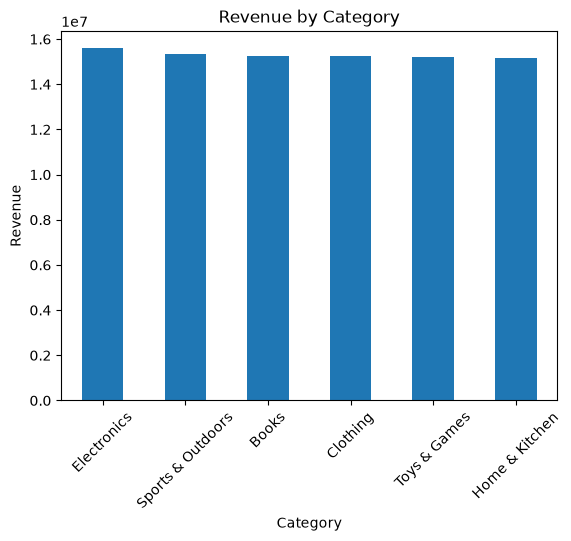

In [8]:
import matplotlib.pyplot as plt

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [9]:
# A chart instantly shows:

# Category ranking
# Revenue distribution
# Relative differences

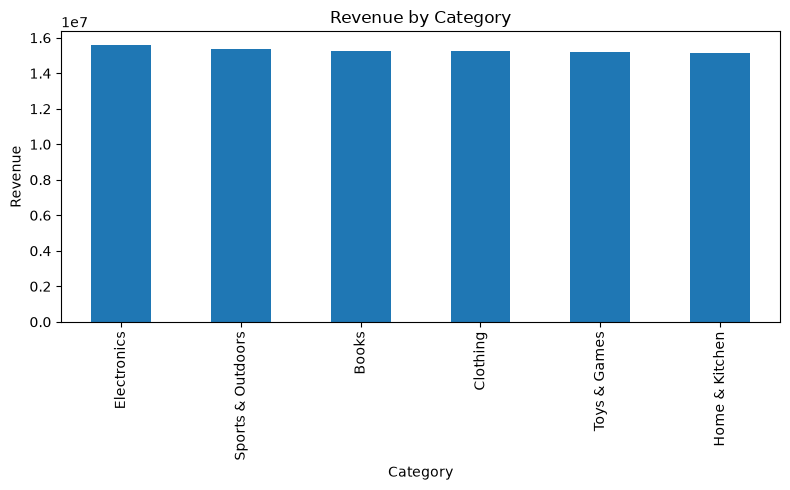

In [10]:
plt.figure(figsize=(8,5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig("images/revenue_by_category.png")

plt.show()

In [11]:
brand_revenue = (
    df.groupby("Brand")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

brand_revenue.head(10)

Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64

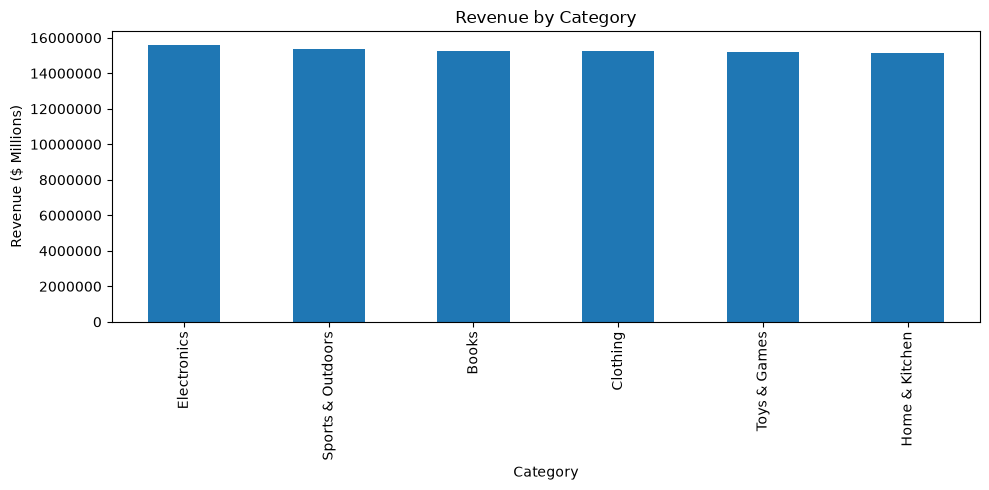

In [13]:
plt.figure(figsize=(10,5))

category_revenue.plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($ Millions)")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.savefig("images/revenue_by_category.png")

plt.show()

In [14]:
brand_revenue = (
    df.groupby("Brand")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

brand_revenue.head(10)

Brand
CoreTech      9343720.59
KiddoFun      9324749.55
ReadMore      9278406.63
UrbanStyle    9249027.45
Zenith        9239960.39
Apex          9147604.72
NexPro        9078824.97
FitLife       9061444.68
BrightLux     9056816.11
HomeEase      9045092.83
Name: TotalAmount, dtype: float64

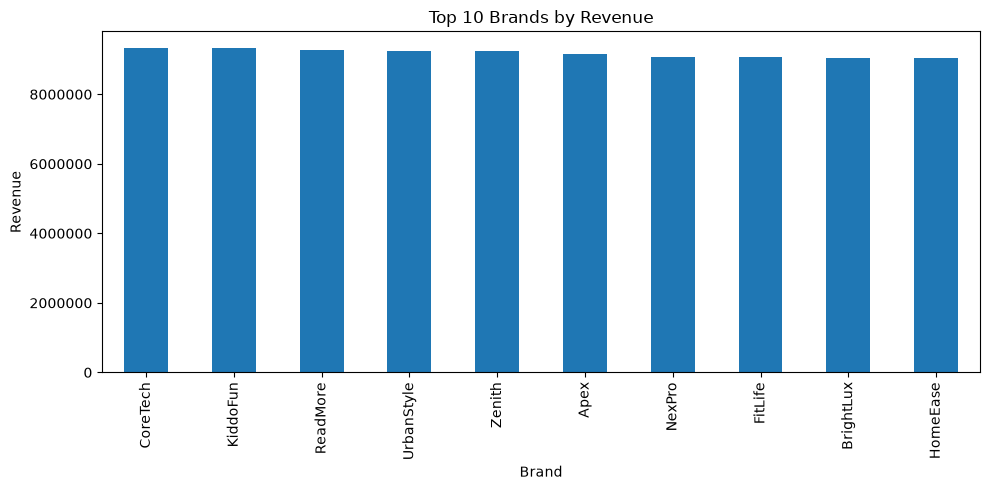

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

brand_revenue.head(10).plot(kind='bar')

plt.title("Top 10 Brands by Revenue")
plt.xlabel("Brand")
plt.ylabel("Revenue")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

In [17]:
monthly_revenue = (
    df.groupby(["Year","Month"])["TotalAmount"]
      .sum()
      .reset_index()
)

monthly_revenue.head()

,Year,Month,TotalAmount
0,2020,1,1637069.40
1,2020,2,1339388.21
2,2020,3,1587125.66
3,2020,4,1588347.29
4,2020,5,1533834.17


In [18]:
monthly_revenue["Date"] = pd.to_datetime(
    monthly_revenue["Year"].astype(str) + "-" +
    monthly_revenue["Month"].astype(str)
)

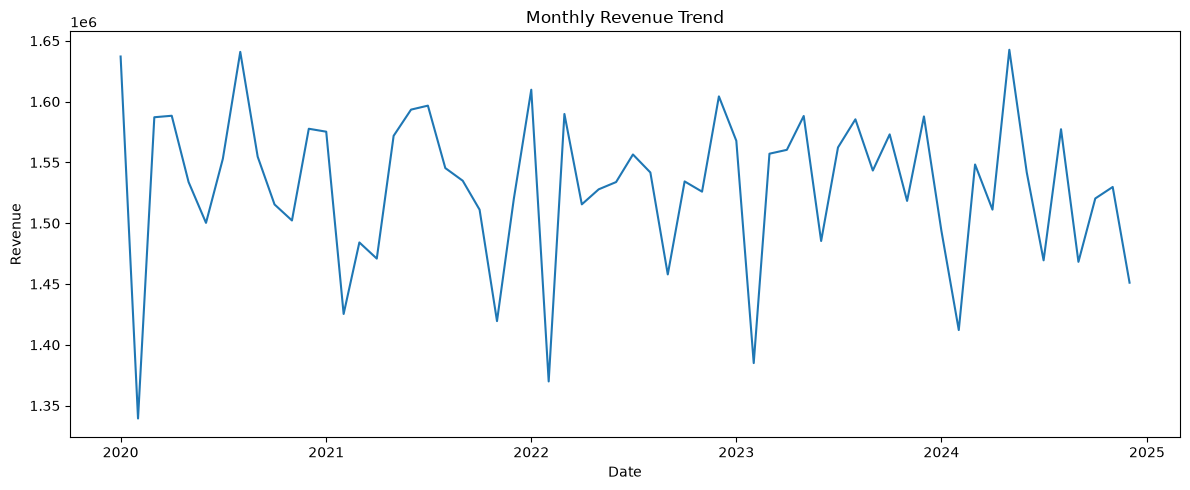

In [19]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["Date"],
    monthly_revenue["TotalAmount"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [20]:
monthly_revenue.sort_values(
    "TotalAmount",
    ascending=False
).head(10)

,Year,Month,TotalAmount,Date
52,2024,5,1642609.94,2024-05-01
7,2020,8,1640874.93,2020-08-01
0,2020,1,1637069.40,2020-01-01
24,2022,1,1609759.87,2022-01-01
35,2022,12,1604276.23,2022-12-01
18,2021,7,1596668.40,2021-07-01
17,2021,6,1593398.08,2021-06-01
26,2022,3,1589809.35,2022-03-01
3,2020,4,1588347.29,2020-04-01
40,2023,5,1588151.65,2023-05-01


In [21]:
top_products = (
    df.groupby("ProductName")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

top_products.head(10)

ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64

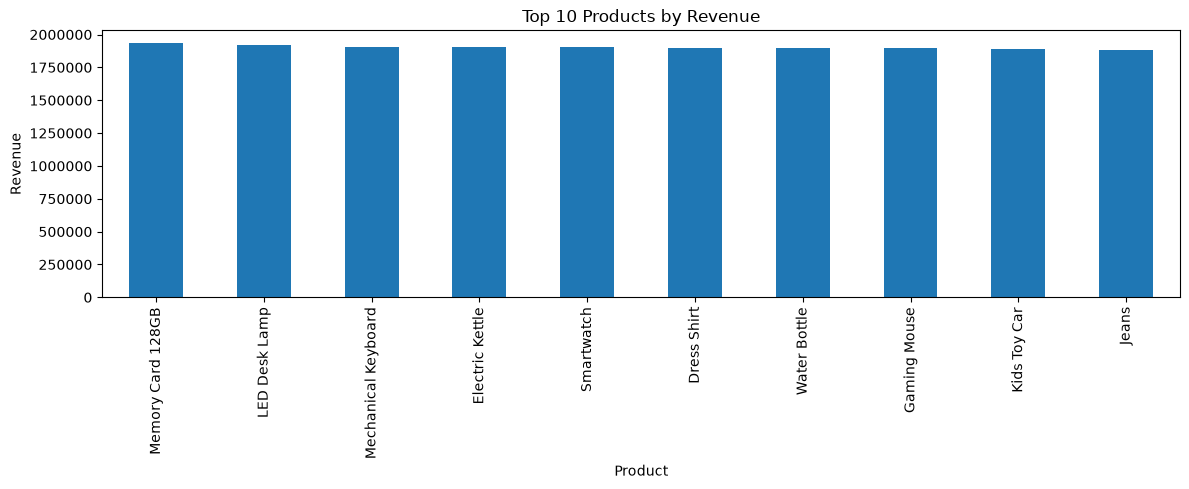

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

In [23]:
df["OrderStatus"].value_counts()

OrderStatus
Delivered    74628
Shipped      15192
Pending       4103
Returned      3049
Cancelled     3028
Name: count, dtype: int64

In [24]:
order_status_revenue = (
    df.groupby("OrderStatus")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

order_status_revenue

OrderStatus
Delivered    68372677.10
Shipped      14083628.99
Pending       3737556.98
Cancelled     2851122.39
Returned      2780662.46
Name: TotalAmount, dtype: float64

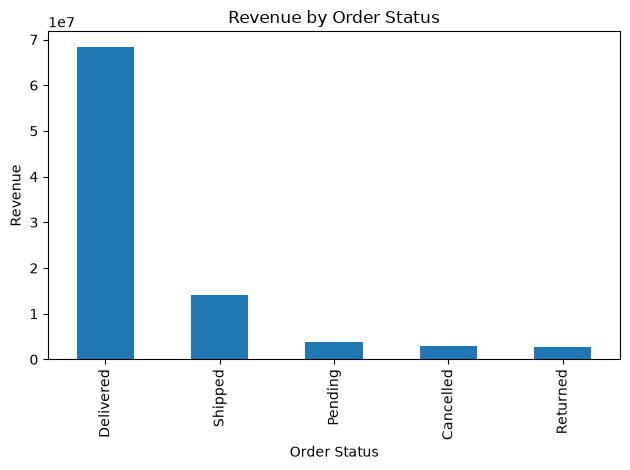

In [25]:
import matplotlib.pyplot as plt

order_status_revenue.plot(kind="bar")

plt.title("Revenue by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [26]:
state_revenue = (
    df.groupby("State")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

state_revenue.head(10)

State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
Name: TotalAmount, dtype: float64

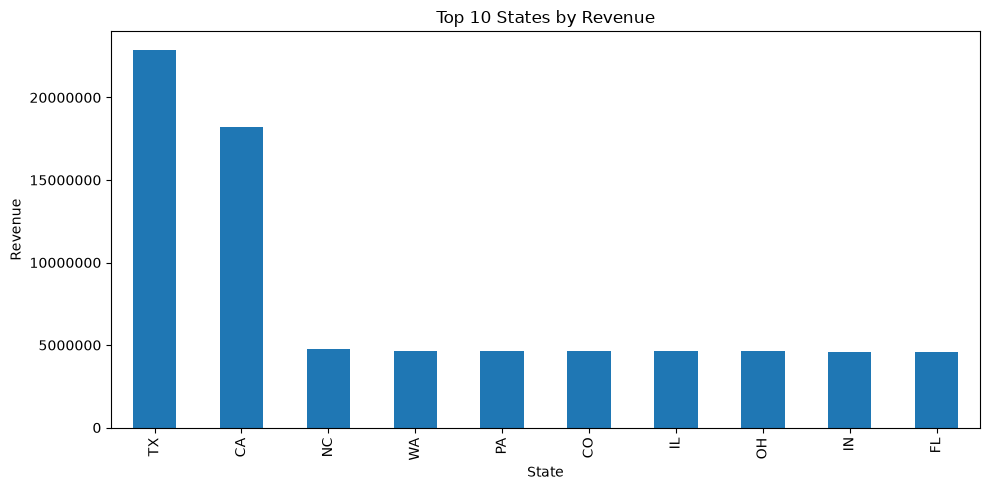

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

state_revenue.head(10).plot(kind='bar')

plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

In [28]:
state_revenue.head(10)

State
TX    22862540.54
CA    18231196.79
NC     4747701.73
WA     4660962.17
PA     4650673.88
CO     4638498.97
IL     4632847.44
OH     4615442.32
IN     4609048.43
FL     4597177.27
Name: TotalAmount, dtype: float64

In [29]:
city_revenue = (
    df.groupby("City")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

city_revenue.head(10)

City
Charlotte       4747701.73
Dallas          4730108.67
San Jose        4669614.33
Seattle         4660962.17
Philadelphia    4650673.88
Denver          4638498.97
Austin          4638403.18
Chicago         4632847.44
Los Angeles     4620629.78
Columbus        4615442.32
Name: TotalAmount, dtype: float64

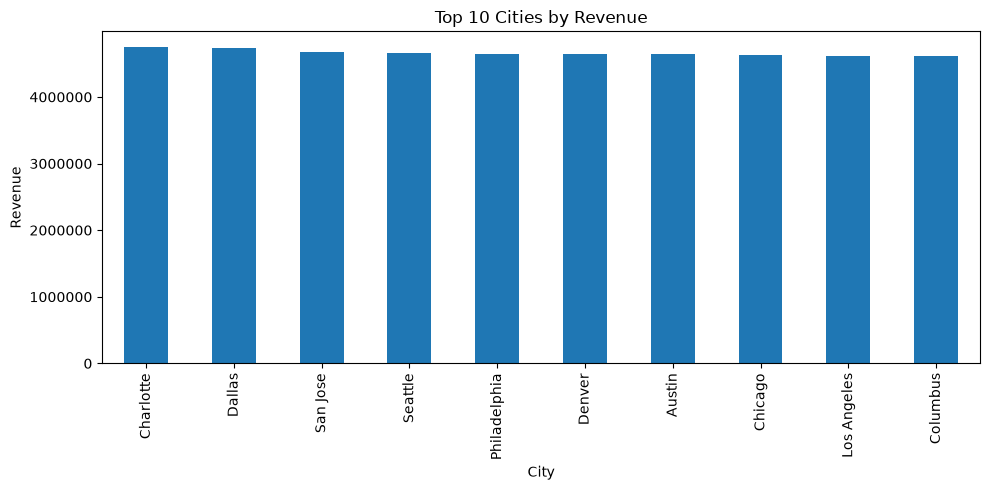

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

city_revenue.head(10).plot(kind='bar')

plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.show()

In [31]:
city_revenue.head(10)

City
Charlotte       4747701.73
Dallas          4730108.67
San Jose        4669614.33
Seattle         4660962.17
Philadelphia    4650673.88
Denver          4638498.97
Austin          4638403.18
Chicago         4632847.44
Los Angeles     4620629.78
Columbus        4615442.32
Name: TotalAmount, dtype: float64

In [32]:
payment_revenue = (
    df.groupby("PaymentMethod")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

payment_revenue

PaymentMethod
Credit Card         32122158.69
Debit Card          18538678.53
UPI                 13896028.55
Amazon Pay          13697498.42
Net Banking          9055674.57
Cash on Delivery     4515609.16
Name: TotalAmount, dtype: float64

In [33]:
df["PaymentMethod"].value_counts()

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64

In [ ]:
# Conclusion

# The analysis revealed that revenue is concentrated among a small group of high-performing categories, brands, and locations.
# These findings can help prioritize marketing investment and inventory planning.